# Distribution Analysis
Output file: `../data/classifications/classifications_for_analysis.csv`.

Load data and expand `labels` into one row per label.

In [1]:
import pandas as pd
import ast


df_classifications_with_others = pd.read_csv(
    "../data/classifications/classifications_with_messages.csv"
)

# labels is a Python-literal string like: [{'reasoning': ..., 'main_category': ..., 'sub_category': ...}]
df_classifications_with_others = df_classifications_with_others.assign(
    parsed_labels=df_classifications_with_others["labels"].map(ast.literal_eval)
)

expanded = df_classifications_with_others.explode("parsed_labels")
expanded["label_rank"] = expanded.groupby(level=0).cumcount() + 1
expanded = expanded.reset_index(drop=True)

parsed_cols = pd.json_normalize(expanded["parsed_labels"])[
    ["reasoning", "main_category", "sub_category"]
]

df_classifications_with_others = pd.concat(
    [expanded.drop(columns=["parsed_labels"]), parsed_cols],
    axis=1,
)

Check `8.1 Others`: row/message counts, label-count distribution, and common content.

In [2]:
others_sub = df_classifications_with_others[
    df_classifications_with_others["sub_category"] == "8.1 Others"
].copy()

if "message_keys" not in globals():
    message_keys = ["sha", "index_in_chat"]

others_row_count = others_sub.shape[0]
others_message_df = others_sub[message_keys].drop_duplicates()
others_message_count = others_message_df.shape[0]

msg_label_counts_all = df_classifications_with_others.groupby(message_keys)[
    "label_rank"
].max()
others_msg_label_counts = msg_label_counts_all.reindex(
    pd.MultiIndex.from_frame(others_message_df)
)

all_single_label = bool((others_msg_label_counts == 1).all())
total_messages = df_classifications_with_others[message_keys].drop_duplicates().shape[0]

print(f"8.1 Others rows: {others_row_count}")
print(
    f"8.1 Others messages: {others_message_count}/{total_messages} ({others_message_count / total_messages:.2%})"
)
print(f"Are all 8.1 Others messages single-label? {all_single_label}")

print("\n8.1 Others label-count distribution (per message):")
print(others_msg_label_counts.value_counts().sort_index())

print("\nTop value_counts of truncated_content in 8.1 Others:")
print(others_sub["truncated_content"].value_counts().head(20))

8.1 Others rows: 1234
8.1 Others messages: 1234/76231 (1.62%)
Are all 8.1 Others messages single-label? False

8.1 Others label-count distribution (per message):
label_rank
1    1233
2       1
Name: count, dtype: int64

Top value_counts of truncated_content in 8.1 Others:
truncated_content
---                1051
?                     7
undefined             7
@nombrechat.mdc       6
.                     5
1                     4
VAN                   4
df                    3
d                     3
test                  3
a                     3
^                     3
h                     2
testing               2
sa                    2
ad                    2
[;'lp,                2
asd;'/l               2
hj                    2
fgh                   2
Name: count, dtype: int64


Drop `8.1 Others` and rebuild a continuous `index_in_chat` per `sha`.

In [3]:
# Drop all 8.1 Others rows into analysis dataframe.
df_classifications = df_classifications_with_others[
    df_classifications_with_others["sub_category"] != "8.1 Others"
].copy()

# Rebuild continuous index_in_chat per sha at message level after dropping Others.
# Preserve original index in index_in_chat_original.
df_classifications = df_classifications.rename(
    columns={"index_in_chat": "index_in_chat_original"}
)

message_index_map = (
    df_classifications[["sha", "index_in_chat_original"]]
    .drop_duplicates()
    .sort_values(["sha", "index_in_chat_original"])
)
message_index_map["index_in_chat"] = message_index_map.groupby("sha").cumcount()

df_classifications = df_classifications.merge(
    message_index_map,
    on=["sha", "index_in_chat_original"],
    how="left",
)
df_classifications["index_in_chat"] = df_classifications["index_in_chat"].astype(int)

print("Rows after dropping 8.1 Others:", len(df_classifications))
print(
    "Remaining 8.1 Others rows:",
    (df_classifications["sub_category"] == "8.1 Others").sum(),
)

Rows after dropping 8.1 Others: 99415
Remaining 8.1 Others rows: 0


Compute main/sub-category percentages using unique messages as the denominator.

In [4]:
import re


def parse_main_key(label):
    match = re.match(r"^\s*(\d+)", str(label))
    return int(match.group(1)) if match else 999


def parse_sub_key(label):
    match = re.match(r"^\s*(\d+)\.(\d+)", str(label))
    return (int(match.group(1)), int(match.group(2))) if match else (999, 999)


# Denominator is unique message count.
message_keys = ["sha", "index_in_chat"]
total_messages = df_classifications[message_keys].drop_duplicates().shape[0]

# Main: same message under same main_category counts once.
main_counts = (
    df_classifications[["main_category", *message_keys]]
    .drop_duplicates()
    .groupby("main_category")
    .size()
)

# Sub: same message under same sub_category counts once.
sub_counts = (
    df_classifications[["sub_category", *message_keys]]
    .drop_duplicates()
    .groupby("sub_category")
    .size()
)

main_pct = main_counts.div(total_messages).mul(100)
sub_pct = sub_counts.div(total_messages).mul(100)

main_sorted = main_pct.sort_index(key=lambda idx: idx.map(parse_main_key))
sub_sorted = sub_pct.sort_index(key=lambda idx: idx.map(parse_sub_key))

sub_by_main = {}
for sub_label, sub_value in sub_sorted.items():
    main_idx, _ = parse_sub_key(sub_label)
    sub_by_main.setdefault(main_idx, []).append((sub_label, sub_value))

In [5]:
# Count unique sub_category labels per message
labels_per_message = (
    df_classifications[["sub_category", *message_keys]]
    .drop_duplicates()
    .groupby(message_keys)["sub_category"]
    .count()
    .rename("label_count")
    .reset_index()
)

# Flag messages with more than one sub_category label
labels_per_message["is_multi"] = labels_per_message["label_count"] > 1

# Join multi-label flag back to sub_category-level records
df_sub_with_multi = (
    df_classifications[["sub_category", *message_keys]]
    .drop_duplicates()
    .merge(labels_per_message[message_keys + ["is_multi"]], on=message_keys)
)

# Multi-label rate per sub_category: share of its messages that carry 2+ labels
sub_multi_rate = df_sub_with_multi.groupby("sub_category")["is_multi"].mean().mul(100)

# Count unique main_category labels per message
main_labels_per_message = (
    df_classifications[["main_category", *message_keys]]
    .drop_duplicates()
    .groupby(message_keys)["main_category"]
    .count()
    .rename("main_label_count")
    .reset_index()
)

# Flag messages with more than one main_category label
main_labels_per_message["is_multi_main"] = (
    main_labels_per_message["main_label_count"] > 1
)

# Join multi-label flag back to main_category-level records
df_main_with_multi = (
    df_classifications[["main_category", *message_keys]]
    .drop_duplicates()
    .merge(main_labels_per_message[message_keys + ["is_multi_main"]], on=message_keys)
)

# Multi-label rate per main_category: share of its messages that carry 2+ main categories
main_multi_rate = (
    df_main_with_multi.groupby("main_category")["is_multi_main"].mean().mul(100)
)

In [6]:
# Print combined results
print(f"Total messages: {total_messages}")
for main_label, main_value in main_sorted.items():
    main_idx = parse_main_key(main_label)
    main_multi = main_multi_rate.get(main_label, 0)
    print(f"{main_label}: {main_value:.2f}%  (multi-label: {main_multi:.2f}%)")
    for sub_label, sub_value in sub_by_main.get(main_idx, []):
        sub_multi = sub_multi_rate.get(sub_label, 0)
        print(f"  {sub_label}: {sub_value:.2f}%  (multi-label: {sub_multi:.2f}%)")
    print()

Total messages: 74998
1. Code Authoring: 34.53%  (multi-label: 35.71%)
  1.1 New Implementation: 5.86%  (multi-label: 35.32%)
  1.2 Iterative Modification: 24.84%  (multi-label: 43.06%)
  1.3 Alignment Correction: 7.21%  (multi-label: 83.63%)

2. Failure Reporting: 24.00%  (multi-label: 27.80%)
  2.1 Log Paste: 8.84%  (multi-label: 39.74%)
  2.2 Symptom Description: 14.77%  (multi-label: 50.76%)
  2.3 Error Persistence: 3.76%  (multi-label: 57.43%)

3. Inquiry: 19.17%  (multi-label: 26.31%)
  3.1 Planning & Decision Consultation: 7.81%  (multi-label: 37.48%)
  3.2 Project Comprehension: 8.19%  (multi-label: 29.38%)
  3.3 General Knowledge Query: 3.56%  (multi-label: 11.35%)

4. Context Specification: 14.08%  (multi-label: 65.42%)
  4.1 Information Injection: 8.46%  (multi-label: 61.86%)
  4.2 Behavior Specification: 6.14%  (multi-label: 77.88%)

5. Validation: 3.99%  (multi-label: 56.14%)
  5.1 Code Review: 2.74%  (multi-label: 51.14%)
  5.2 Runtime Inspection: 1.26%  (multi-label: 67.

Summarize single-label vs multi-label message ratios and mean labels per message.

In [7]:
msg_label_counts = df_classifications.groupby(message_keys)["label_rank"].max()

total_messages = msg_label_counts.shape[0]
multi_counts = msg_label_counts[msg_label_counts >= 2].value_counts().sort_index()
multi_pct = multi_counts.div(total_messages).mul(100)

print(
    f"Single-label messages: {(msg_label_counts == 1).mean():.1%} ({(msg_label_counts == 1).sum()}/{total_messages})"
)
print(
    f"Multi-label messages: {(msg_label_counts > 1).mean():.1%} ({multi_counts.sum()}/{total_messages})"
)

print("Multi-label message ratios:")
for n in range(2, msg_label_counts.max() + 1):
    print(
        f"  {n}: {multi_pct.get(n, 0):.2f}% ({multi_counts.get(n, 0)}/{total_messages})"
    )

print(f"Mean labels per message: {msg_label_counts.mean():.2f}")

Single-label messages: 70.1% (52596/74998)
Multi-label messages: 29.9% (22402/74998)
Multi-label message ratios:
  2: 27.45% (20588/74998)
  3: 2.17% (1631/74998)
  4: 0.22% (166/74998)
  5: 0.02% (16/74998)
  6: 0.00% (1/74998)
Mean labels per message: 1.33


Count co-occurring sub-category pairs in multi-label messages.

In [8]:
from itertools import combinations

# Build unique sub-category sets per message.
msg_sub_sets = df_classifications.groupby(message_keys)["sub_category"].apply(
    lambda s: tuple(sorted(set(s.dropna())))
)

# Keep only multi-label messages (at least 2 distinct sub-categories).
multi_msg_sub_sets = msg_sub_sets[msg_sub_sets.map(len) >= 2]

# Denominator for ratio: all messages.
total_messages = msg_sub_sets.shape[0]

pair_counts = {}
for sub_tuple in multi_msg_sub_sets:
    for pair in combinations(sub_tuple, 2):
        pair_counts[pair] = pair_counts.get(pair, 0) + 1

pair_pct = (
    pd.Series(pair_counts, dtype=float)
    .sort_values(ascending=False)
    .div(total_messages)
    .mul(100)
)

print(f"All messages used as denominator: {total_messages}")
print(f"Multi-label messages contributing pairs: {multi_msg_sub_sets.shape[0]}")
print(f"Unique sub-category pairs: {pair_pct.shape[0]}")
print("\nTop 10 pair ratios among all messages:")
for (sub1, sub2), pct in pair_pct.head(10).items():
    print(f"{sub1} + {sub2}: {pct:.2f}%")

All messages used as denominator: 74998
Multi-label messages contributing pairs: 22402
Unique sub-category pairs: 179

Top 10 pair ratios among all messages:
1.2 Iterative Modification + 1.3 Alignment Correction: 3.10%
2.1 Log Paste + 2.2 Symptom Description: 2.17%
1.2 Iterative Modification + 2.2 Symptom Description: 1.91%
1.2 Iterative Modification + 6.2 Toolchain Operation: 1.36%
1.2 Iterative Modification + 4.1 Information Injection: 1.21%
1.2 Iterative Modification + 4.2 Behavior Specification: 1.00%
4.2 Behavior Specification + 6.2 Toolchain Operation: 0.99%
6.1 Documentation + 6.2 Toolchain Operation: 0.88%
2.2 Symptom Description + 2.3 Error Persistence: 0.78%
1.3 Alignment Correction + 2.2 Symptom Description: 0.78%


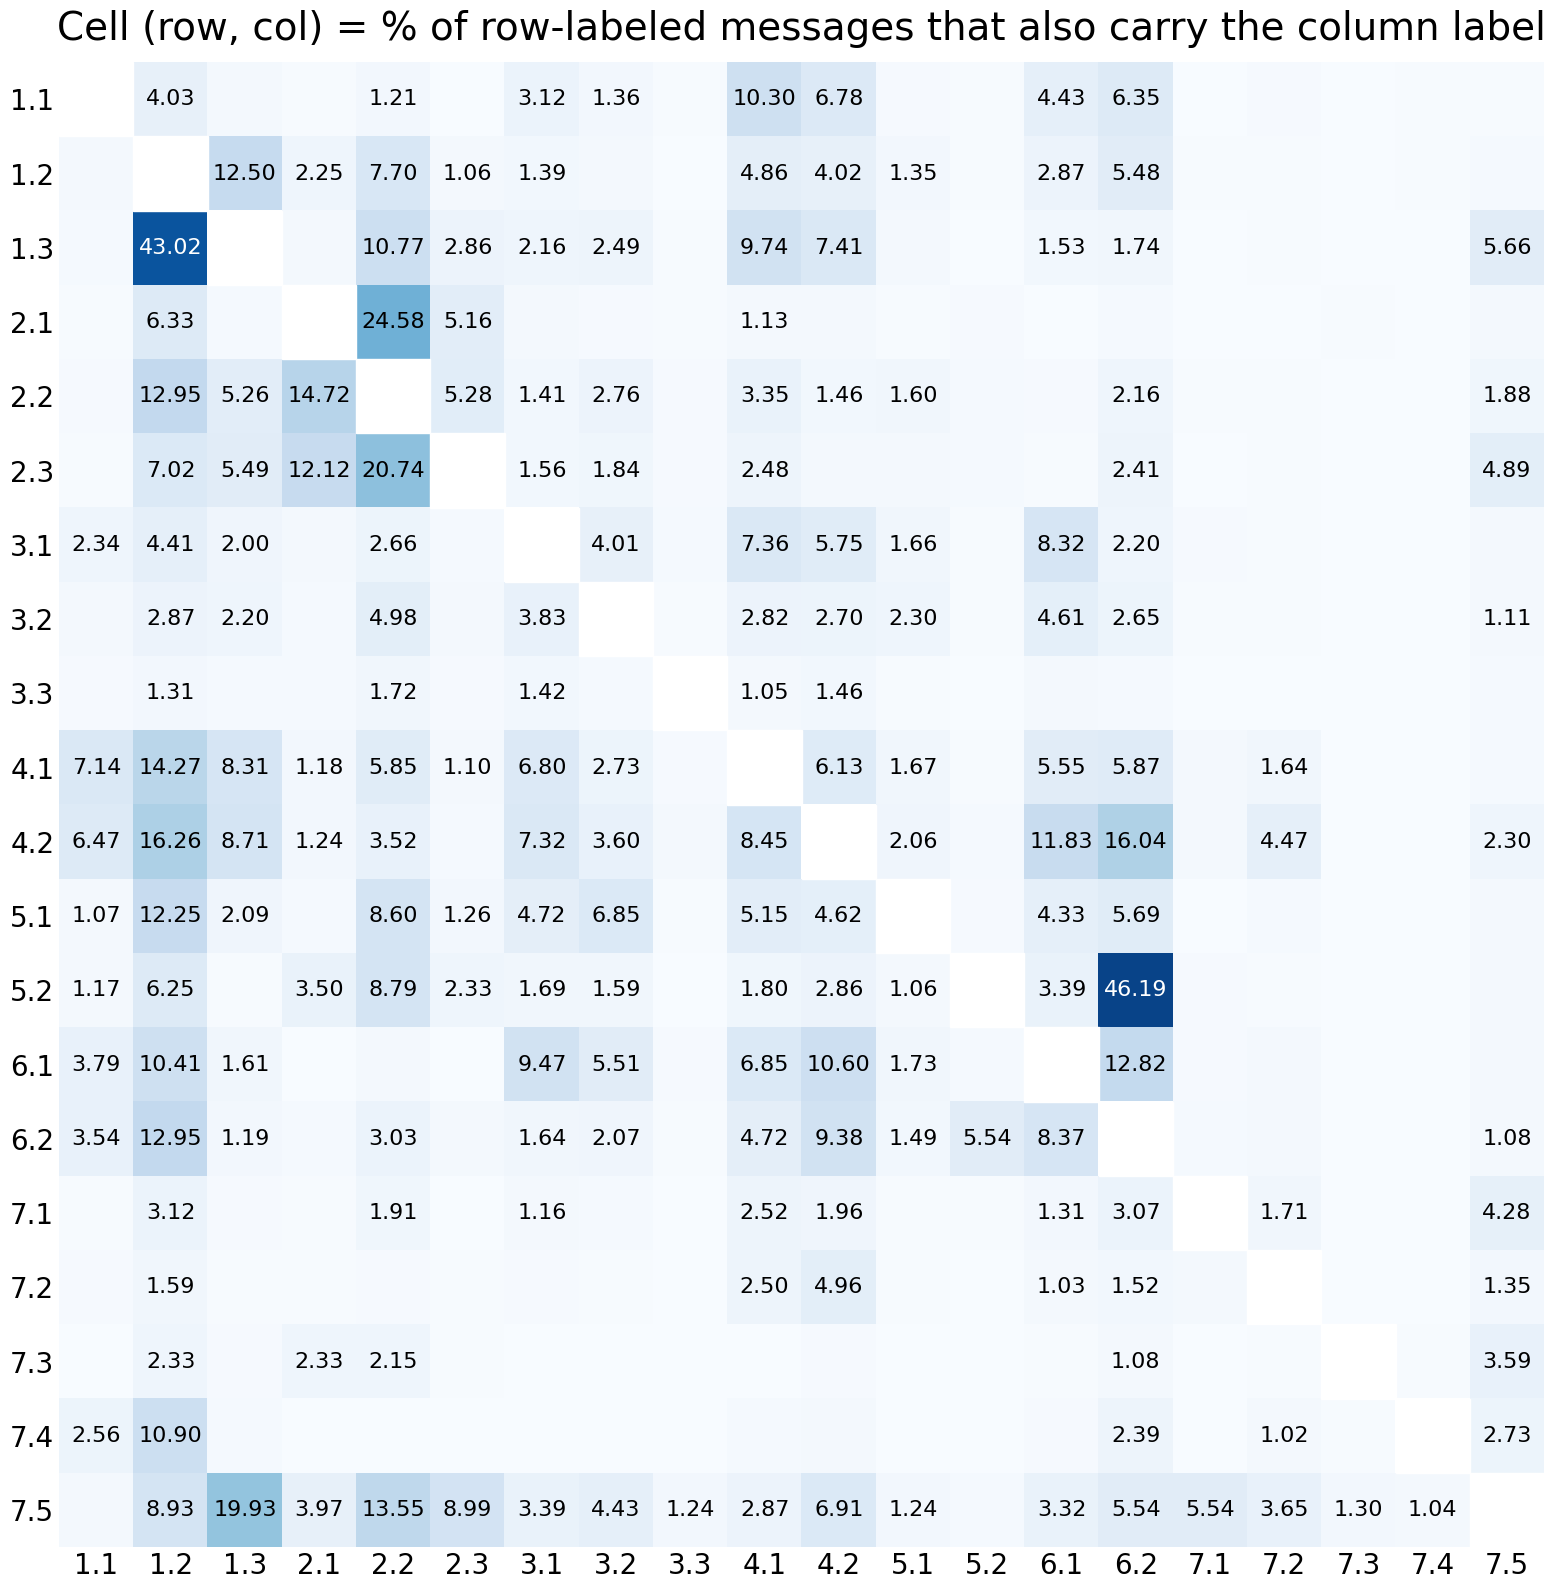

,anchor,co_label,pct,n_messages
1,5.2 Runtime Inspection,6.2 Toolchain Operation,46.19,436
2,1.3 Alignment Correction,1.2 Iterative Modification,43.02,2328
3,2.1 Log Paste,2.2 Symptom Description,24.58,1630
4,2.3 Error Persistence,2.2 Symptom Description,20.74,585
5,7.5 Sentiment Expression,1.3 Alignment Correction,19.93,306
6,4.2 Behavior Specification,1.2 Iterative Modification,16.26,749
7,4.2 Behavior Specification,6.2 Toolchain Operation,16.04,739
8,2.2 Symptom Description,2.1 Log Paste,14.72,1630
9,4.1 Information Injection,1.2 Iterative Modification,14.27,905
10,7.5 Sentiment Expression,2.2 Symptom Description,13.55,208


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from categories import VALID_CATEGORIES

# ── 1. Subcategory list (taxonomy order, excluding Others) ─────────────────────
SUBCATEGORIES = [
    sub
    for main, subs in VALID_CATEGORIES.items()
    for sub in subs
    if main != "8. Others"
]

# Fix label name
SUBCATEGORIES = [
    "3.1 Planning & Consultation" if s == "3.1 Planning & Decision Consultation" else s
    for s in SUBCATEGORIES
]

n = len(SUBCATEGORIES)
idx = {s: i for i, s in enumerate(SUBCATEGORIES)}

# ── 2. Message-level label sets ────────────────────────────────────────────────
msg_labels = (
    df_classifications.groupby(["sha", "index_in_chat"])["sub_category"]
    .apply(set)
    .reset_index(name="label_set")
)


# Remap label in data as well
def remap_labels(label_set):
    return {
        (
            "3.1 Planning & Consultation"
            if l == "3.1 Planning & Decision Consultation"
            else l
        )
        for l in label_set
    }


msg_labels["label_set"] = msg_labels["label_set"].apply(remap_labels)

# ── 3. Co-occurrence counts ────────────────────────────────────────────────────
count = np.zeros((n, n), dtype=float)
for label_set in msg_labels["label_set"]:
    present = [l for l in label_set if l in idx]
    for a in present:
        for b in present:
            count[idx[a], idx[b]] += 1

# Normalize: P(col | row)
row_totals = np.diag(count)
with np.errstate(divide="ignore", invalid="ignore"):
    cooc = np.where(row_totals[:, None] > 0, count / row_totals[:, None], 0.0)

# ── 4. Plot ────────────────────────────────────────────────────────────────────
cmap = plt.cm.Blues

fig, ax = plt.subplots(figsize=(16, 16))  # square figure

for spine in ax.spines.values():
    spine.set_visible(False)  # hide spines for cleaner look

# Mask diagonal
cooc_plot = cooc.copy()
np.fill_diagonal(cooc_plot, np.nan)

im = ax.imshow(cooc_plot, cmap=cmap, vmin=0, vmax=0.5, aspect="equal")  # square cells

# Diagonal → white (leave blank)
for i in range(n):
    ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1, color="white", zorder=1))

# Annotate off-diagonal cells (≥1%)
for i in range(n):
    for j in range(n):
        if i == j:
            continue
        val = cooc[i, j]
        if val < 0.01:
            continue
        text_color = "white" if val > 0.35 else "black"
        ax.text(
            j,
            i,
            f"{val*100:.2f}",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="medium",
            color=text_color,
            zorder=3,
        )

# Tick labels — large font
short_labels = [s.split(" ")[0] for s in SUBCATEGORIES]
ax.set_xticks(range(n))
ax.set_xticklabels(short_labels, fontsize=20)
ax.set_yticks(range(n))
ax.set_yticklabels(short_labels, fontsize=20)

ax.set_title(
    "Cell (row, col) = % of row-labeled messages that also carry the column label",
    fontsize=28,
    pad=16,
)
ax.tick_params(axis="both", which="both", length=0)  # hide tick marks

plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/cooccurrence_heatmap.pdf", bbox_inches="tight")
plt.show()

# ── 5. Top 20 off-diagonal pairs ───────────────────────────────────────────────
records = [
    {
        "anchor": SUBCATEGORIES[i],
        "co_label": SUBCATEGORIES[j],
        "pct": round(cooc[i, j] * 100, 2),
        "n_messages": int(count[i, j]),
    }
    for i in range(n)
    for j in range(n)
    if i != j and cooc[i, j] >= 0.01
]
top20 = (
    pd.DataFrame(records)
    .sort_values("pct", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top20.index += 1
display(top20)

Export the cleaned analysis dataset to CSV.

In [10]:
df_classifications.to_csv(
    "../data/classifications/classifications_for_analysis.csv", index=False
)